## Подготовка для обучения в google colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
repo_path = '/content/ML'

if not os.path.exists(repo_path):
    !git clone https://github.com/EseaHub/ML.git
    %cd ML/spam_bert_project
else:
    %cd ML/spam_bert_project
    !git pull

/content/ML/spam_bert_project
Already up to date.


In [ ]:
!pip install transformers datasets[torch] scikit-learn --quiet

## Загрузка и анализ данных

In [ ]:
import pandas as pd
import numpy as np
import os

os.makedirs('data', exist_ok=True)

!wget -O data/spam.csv https://raw.githubusercontent.com/mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv

--2026-03-10 14:45:18--  https://raw.githubusercontent.com/mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [application/octet-stream]
Saving to: ‘data/spam.csv’

data/spam.csv       100%[===================>] 491.86K  --.-KB/s    in 0.02s   

2026-03-10 14:45:19 (29.0 MB/s) - ‘data/spam.csv’ saved [503663/503663]



In [ ]:
df = pd.read_csv('data/spam.csv', encoding='latin-1')
print(f"Исходная форма датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

Исходная форма датасета: (5572, 5)
Колонки: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [ ]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [ ]:
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [ ]:
df

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


### Дубликаты/пропуски

In [ ]:
print(f"Пропуски в label: {df['label'].isnull().sum()}")
print(f"Пропуски в text: {df['text'].isnull().sum()}")
print(f"Дубликаты: {df.duplicated().sum()}")


Пропуски в label: 0
Пропуски в text: 0
Дубликаты: 403


In [ ]:
df[df.duplicated()]

,label,text
102,0,As per your request 'Melle Melle (Oru Minnamin...
153,0,As per your request 'Melle Melle (Oru Minnamin...
206,0,"As I entered my cabin my PA said, '' Happy B'd..."
222,0,"Sorry, I'll call later"
325,0,No calls..messages..missed calls
...,...,...
5524,1,You are awarded a SiPix Digital Camera! call 0...
5535,0,"I know you are thinkin malaria. But relax, chi..."
5539,0,Just sleeping..and surfing
5553,0,Hahaha..use your brain dear


❗ Удалим строки полностью дублирующие друг друга (метка + текст), а потом проверим нет ли аномальных данных, где текст был одинаковый, а метка разная

In [ ]:
df = df.drop_duplicates(keep='first')
text_dupes = df[df.duplicated(subset=['text'], keep=False)]
print(f"Аномальных строк: {len(text_dupes)}")

Аномальных строк: 0


In [ ]:
df

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


### Распределение классов

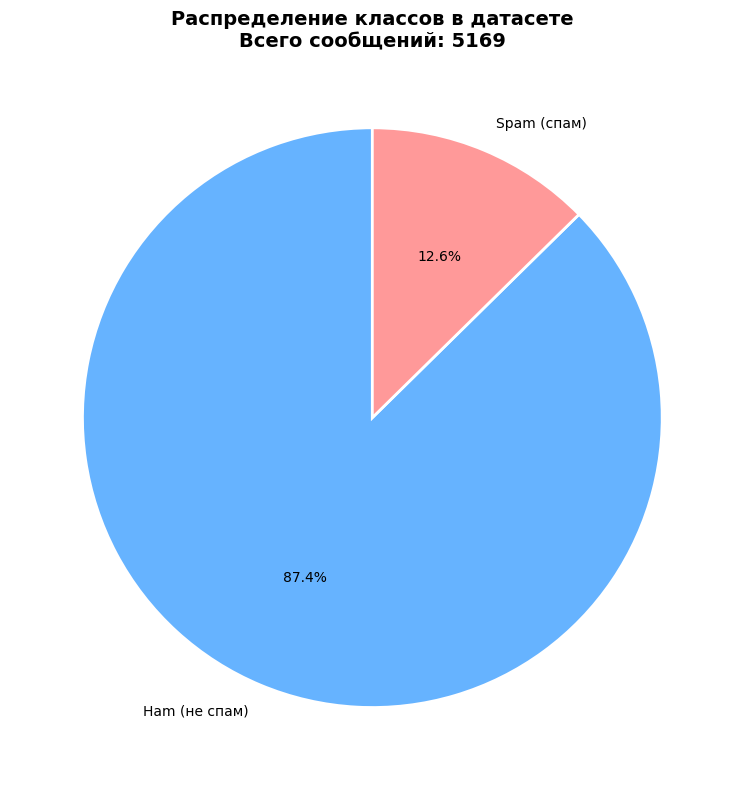

Ham (не спам): 4516 сообщений
Spam (спам): 653 сообщений
Соотношение: 1 к 6.9


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

counts = df['label'].value_counts()
labels = ['Ham (не спам)', 'Spam (спам)']
sizes = [counts[0], counts[1]]


plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=['#66b3ff', '#ff9999'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title(f'Распределение классов в датасете\nВсего сообщений: {len(df)}',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Ham (не спам): {counts[0]} сообщений")
print(f"Spam (спам): {counts[1]} сообщений")
print(f"Соотношение: 1 к{counts[0]/counts[1]: .1f}")

### Проверка длины сообщений

In [ ]:
df['text_length'] = df['text'].str.len()
print(f"Общая средняя длина: {df['text_length'].mean():.0f} символов")
print(f"Максимальная длина: {df['text_length'].max()}")
print(f"Минимальная длина: {df['text_length'].min()}")

print(f"\nСредняя длина спам-сообщений: {df[df['label']==1]['text_length'].mean():.0f}")
print(f"Средняя длина обычных сообщений: {df[df['label']==0]['text_length'].mean():.0f}")

Общая средняя длина: 79 символов
Максимальная длина: 910
Минимальная длина: 2

Средняя длина спам-сообщений: 138
Средняя длина обычных сообщений: 70


/tmp/ipykernel_725/277796824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text_length'] = df['text'].str.len()


## Подготовка данных для BERT

In [ ]:
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
import numpy as np

In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label'].values
)

print(f"Обучающая выборка: {len(train_texts)} сообщений")
print(f"Валидационная выборка: {len(val_texts)} сообщений")

Обучающая выборка: 4135 сообщений
Валидационная выборка: 1034 сообщений


In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print(f"Размер словаря: {tokenizer.vocab_size}")
print(f"Максимальная длина: {tokenizer.model_max_length}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Размер словаря: 30522
Максимальная длина: 512


In [ ]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128,   # исходя из проведенного анализа длин сообщений
    return_tensors='pt'  # возвращаем тензоры
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

print(f"Форма train тензоров: {train_encodings['input_ids'].shape}")
print(f"Форма val тензоров: {val_encodings['input_ids'].shape}")

Форма train тензоров: torch.Size([4135, 128])
Форма val тензоров: torch.Size([1034, 128])


Создание датасета

In [ ]:
from torch.utils.data import Dataset
import torch

In [ ]:
class SpamDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = SpamDataset(train_encodings, train_labels)
val_dataset = SpamDataset(val_encodings, val_labels)

print(f"Размер train датасета: {len(train_dataset)} примеров")
print(f"Размер val датасета: {len(val_dataset)} примеров")


Размер train датасета: 4135 примеров
Размер val датасета: 1034 примеров


In [ ]:
# sample = train_dataset[0]

# print(f"input_ids shape: {sample['input_ids'].shape}")
# print(f"attention_mask shape: {sample['attention_mask'].shape}")
# print(f"label: {sample['labels']}")

# print(f"\nПервые 10 токенов: {sample['input_ids'][:10].tolist()}")
# print(f"Соответствующие слова: {tokenizer.decode(sample['input_ids'][:10])}")


## Взвешивание весов

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

In [ ]:
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),  #  1 - spam
    y=train_labels
)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print(f"Тензор весов: {class_weights}")
print(f"Устройство: {device}")

Тензор весов: tensor([0.5722, 3.9607], device='cuda:0')
Устройство: cuda


## Инициализация BERT

In [ ]:
from transformers import BertForSequenceClassification
import torch

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    ignore_mismatched_sizes=True  # игнорируем несоответствие размеров
)

model.to(device)
print(f"✅ Модель загружена и перемещена на {device}")


total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Модель загружена и перемещена на cuda
Всего параметров: 109,483,778
Обучаемых параметров: 109,483,778


🔧 Архитектура модели


In [ ]:
print(f"Тип: {model.__class__.__name__}")
print(f"Количество слоев: {model.config.num_hidden_layers}")
print(f"Размер hidden слоя: {model.config.hidden_size}")
print(f"Количество голов attention: {model.config.num_attention_heads}")

Тип: BertForSequenceClassification
Количество слоев: 12
Размер hidden слоя: 768
Количество голов attention: 12


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',

    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,                 # L2 регуляризация

    logging_dir='./logs',
    logging_steps=50,
    save_strategy='epoch',
    eval_strategy='epoch',
    load_best_model_at_end=True,

    metric_for_best_model='f1',
    greater_is_better=True,

    warmup_ratio=0.1,
    report_to='none',                     # не отправлять отчеты в сторонние сервисы
    seed=42,
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Написание кастомого Trainer для обучения весов

In [ ]:
import torch.nn as nn
from transformers import Trainer

In [ ]:
class WeightedTrainer(Trainer):

    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')

        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

print(f"Веса классов будут использоваться: ham={class_weights[0]:.3f}, spam={class_weights[1]:.3f}")

Веса классов будут использоваться: ham=0.572, spam=3.961


## Обучение

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


In [ ]:
trainer = WeightedTrainer(
    class_weights=class_weights,           # наши веса
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)


In [ ]:
trainer.train()

print("\n✅ Обучение завершено!")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.067700,0.060751,0.983559,0.895833,0.984733,0.938182
2,0.000247,0.082728,0.990329,0.948148,0.977099,0.962406
3,0.000287,0.119301,0.991296,0.969231,0.961832,0.965517


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ Обучение завершено!


## Сохраняем модель


In [ ]:
model_save_path = '/content/drive/MyDrive/spam_bert_model'
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"Модель сохранена в {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель сохранена в /content/drive/MyDrive/spam_bert_model


In [ ]:
def predict_spam(text):
    model.eval()
    inputs = tokenizer(text, return_tensors='pt', truncation=True,
                      padding=True, max_length=128).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()

    return {
        'text': text,
        'is_spam': bool(pred),
        'spam_probability': probs[0][1].item()
    }

# Тестовые сообщения
test_messages = [
    "WINNER!! You have won a free ticket to Bahamas! Call now!",
    "Hey, are we still meeting for coffee tomorrow?",
    "Congratulations! You've been selected for a $1000 gift card!",
    "Can you pick up some milk on your way home?",
    "URGENT: Your account has been compromised. Click here to secure it.",
    "Free entry to 2 wkly comp to win FA Cup final tkts 21st May 2005.",
    "Hi Mom, I'll be home late tonight, don't wait up."
]

print("\n🔍 ТЕСТИРОВАНИЕ МОДЕЛИ:")
print("="*50)
for msg in test_messages:
    result = predict_spam(msg)
    spam_emoji = "🚫" if result['is_spam'] else "✅"
    print(f"\n{spam_emoji} Текст: {result['text']}")
    print(f"   Спам: {result['is_spam']}")
    print(f"   Вероятность спама: {result['spam_probability']:.4f}")


🔍 ТЕСТИРОВАНИЕ МОДЕЛИ:

🚫 Текст: WINNER!! You have won a free ticket to Bahamas! Call now!
   Спам: True
   Вероятность спама: 1.0000

✅ Текст: Hey, are we still meeting for coffee tomorrow?
   Спам: False
   Вероятность спама: 0.0001

🚫 Текст: Congratulations! You've been selected for a $1000 gift card!
   Спам: True
   Вероятность спама: 0.9997

✅ Текст: Can you pick up some milk on your way home?
   Спам: False
   Вероятность спама: 0.0001

🚫 Текст: URGENT: Your account has been compromised. Click here to secure it.
   Спам: True
   Вероятность спама: 0.9953

🚫 Текст: Free entry to 2 wkly comp to win FA Cup final tkts 21st May 2005.
   Спам: True
   Вероятность спама: 0.9999

✅ Текст: Hi Mom, I'll be home late tonight, don't wait up.
   Спам: False
   Вероятность спама: 0.0001
